<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/Vergleich_2024_mit_Gesamtzeitraum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Geodataframe für LST 2024 erstellen
- KNN-Matrix für alle Städte
- GI* Analyse und Cold-Spot Klassifizierung für alle Städte
- Visualisierung und Vergleich mit Zeitraum 2019-2024

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import geopandas as gpd

In [ ]:
all_cities_summer_avg_lst_per_pixel = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/all_cities_summer_avg_lst_per_pixel_allyears.geojson")
display(all_cities_summer_avg_lst_per_pixel.head())

,longitude,latitude,year,city,avg_summer_LST_Celsius,geometry
0,9.080523,50.007251,2019,Aschaffenburg,32.516656,POINT (9.08052 50.00725)
1,9.080524,50.007521,2019,Aschaffenburg,32.417533,POINT (9.08052 50.00752)
2,9.080524,50.007791,2019,Aschaffenburg,32.320120,POINT (9.08052 50.00779)
3,9.080941,50.006711,2019,Aschaffenburg,32.817441,POINT (9.08094 50.00671)
4,9.080941,50.006981,2019,Aschaffenburg,32.648249,POINT (9.08094 50.00698)


# Geodataframe für 2024

In [ ]:
# Filter the geodataframe for the year 2024
gdf_2024 = all_cities_summer_avg_lst_per_pixel[all_cities_summer_avg_lst_per_pixel['year'] == 2024].copy()

print(gdf_2024.head())

        longitude   latitude  year           city  avg_summer_LST_Celsius  \
292706   9.080523  50.007251  2024  Aschaffenburg               15.599166   
292707   9.080524  50.007521  2024  Aschaffenburg               15.445355   
292708   9.080524  50.007791  2024  Aschaffenburg               15.342814   
292709   9.080941  50.006711  2024  Aschaffenburg               16.146049   
292710   9.080941  50.006981  2024  Aschaffenburg               15.848681   

                        geometry  
292706  POINT (9.08052 50.00725)  
292707  POINT (9.08052 50.00752)  
292708  POINT (9.08052 50.00779)  
292709  POINT (9.08094 50.00671)  
292710  POINT (9.08094 50.00698)  


## Geodataframe 2024 speichern

In [ ]:
# Define the output path in Google Drive
output_path = "/content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson"

# Save the geodataframe to a GeoJSON file
gdf_2024.to_file(output_path, driver='GeoJSON')

print(f"Geodataframe 'gdf_2024' erfolgreich gespeichert als: {output_path}")

Geodataframe 'gdf_2024' erfolgreich gespeichert als: /content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson


## Geodataframe wieder laden

In [3]:
# Define the path to the GeoJSON file in Google Drive
input_path = "/content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson"

# Read the GeoJSON file into a geodataframe
loaded_gdf_2024 = gpd.read_file(input_path)

# Display the first few rows of the loaded geodataframe to verify
display(loaded_gdf_2024.head())

,longitude,latitude,year,city,avg_summer_LST_Celsius,geometry
0,9.080523,50.007251,2024,Aschaffenburg,15.599166,POINT (9.08052 50.00725)
1,9.080524,50.007521,2024,Aschaffenburg,15.445355,POINT (9.08052 50.00752)
2,9.080524,50.007791,2024,Aschaffenburg,15.342814,POINT (9.08052 50.00779)
3,9.080941,50.006711,2024,Aschaffenburg,16.146049,POINT (9.08094 50.00671)
4,9.080941,50.006981,2024,Aschaffenburg,15.848681,POINT (9.08094 50.00698)


## KNN-Matrix 2024 erstellen

In [ ]:
import libpysal as lps
import pandas as pd

# Initialize a dictionary to store the KNN weights matrices for each city
knn_weights_matrices = {}

# Get the unique cities from the geodataframe
cities = gdf_2024['city'].unique()

# Iterate through each city and create the KNN weights matrix
for city in cities:
    print(f"Creating KNN weights matrix for {city}...")
    # Filter the geodataframe for the current city
    gdf_city = gdf_2024[gdf_2024['city'] == city].copy()

    # Create the KNN weights matrix with k=12
    # Ensure that the number of neighbors (k) is not greater than the number of observations in the city's geodataframe
    k_neighbors = min(12, len(gdf_city) - 1) if len(gdf_city) > 1 else 0

    if k_neighbors > 0:
        wq = lps.weights.KNN.from_dataframe(gdf_city, k=k_neighbors)
        knn_weights_matrices[city] = wq
        print(f"KNN weights matrix created for {city} with k={k_neighbors}.")
    else:
        print(f"Skipping KNN weights matrix creation for {city} as it has {len(gdf_city)} observation(s).")


# You can now access the weights matrix for each city using the dictionary
# For example, to access the weights matrix for Munich:
# munich_wq = knn_weights_matrices['Munich']

# To store the weights matrices, you could iterate through the dictionary and save each one
# For example, saving to a file (e.g., using pickle or saving to a sparse matrix format if needed)
# import pickle
# with open('knn_weights_matrices.pkl', 'wb') as f:
#     pickle.dump(knn_weights_matrices, f)

print("\nKNN weights matrices created for all cities and stored in the 'knn_weights_matrices' dictionary.")

Creating KNN weights matrix for Aschaffenburg...
KNN weights matrix created for Aschaffenburg with k=12.
Creating KNN weights matrix for Augsburg...
KNN weights matrix created for Augsburg with k=12.
Creating KNN weights matrix for Bamberg...
KNN weights matrix created for Bamberg with k=12.
Creating KNN weights matrix for Bayreuth...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Bayreuth with k=12.
Creating KNN weights matrix for Erlangen...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Erlangen with k=12.
Creating KNN weights matrix for Fürth...
KNN weights matrix created for Fürth with k=12.
Creating KNN weights matrix for Ingolstadt...
KNN weights matrix created for Ingolstadt with k=12.
Creating KNN weights matrix for Kempten (Allgäu)...


...

KNN weights matrix created for Kempten (Allgäu) with k=12.
Creating KNN weights matrix for Landshut...
KNN weights matrix created for Landshut with k=12.
Creating KNN weights matrix for Munich...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Munich with k=12.
Creating KNN weights matrix for Nuremberg...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Nuremberg with k=12.
Creating KNN weights matrix for Passau...
KNN weights matrix created for Passau with k=12.
Creating KNN weights matrix for Regensburg...
KNN weights matrix created for Regensburg with k=12.
Creating KNN weights matrix for Rosenheim...
KNN weights matrix created for Rosenheim with k=12.
Creating KNN weights matrix for Schweinfurt...
KNN weights matrix created for Schweinfurt with k=12.
Creating KNN weights matrix for Würzburg...
KNN weights matrix created for Würzburg with k=12.

KNN weights matrices created for all cities and stored in the 'knn_weights_matrices' dictionary.


## KNN-Matrix speichern

In [ ]:
import os
import libpysal as ps # libpysal wird zum Speichern benötigt

# Definieren Sie den Ordner, in dem die Gewichtsmatrizen gespeichert werden sollen
# Passen Sie diesen Pfad bei Bedarf an, idealerweise in Ihrem Google Drive
output_weights_folder = "/content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/" # Adjusted folder name
os.makedirs(output_weights_folder, exist_ok=True) # Erstellt den Ordner, falls er nicht existiert

print(f"Speichere KNN-Gewichtsmatrizen im Ordner: {output_weights_folder}")

# Schleife über das Dictionary und speichern Sie jede Gewichtsmatrix
for city, w_matrix in knn_weights_matrices.items(): # Using the correct dictionary variable name
    if w_matrix is not None:
        # Erstellen Sie einen Dateinamen basierend auf dem Stadtnamen
        # Verwenden Sie ein Format, das von libpysal unterstützt wird, z.B. .gal oder .gwt
        # Für KNN ist .gwt (General Weights format) oft passend, aber .gal funktioniert auch oft.
        # Wir verwenden hier .gal als Beispiel.
        file_name = f"{city.replace(' ', '_')}_knn_k12.gal" # Adjusted filename
        file_path = os.path.join(output_weights_folder, file_name)

        try:
            # Speichern Sie die Gewichtsmatrix mit libpysal.io.open()
            # Verwenden Sie nicht den context manager (with), da GalIO ihn nicht unterstützt
            f = ps.io.open(file_path, mode='w')
            f.write(w_matrix)
            f.close() # Datei explizit schließen

            print(f"  Gewichtsmatrix für {city} gespeichert unter: {file_path}")
        except Exception as e:
            print(f"  Fehler beim Speichern der Gewichtsmatrix für {city}: {e}")
    else:
        print(f"  Keine Gewichtsmatrix für {city} verfügbar zum Speichern.")

print("\nSpeichern der KNN-Gewichtsmatrizen abgeschlossen.")

Speichere KNN-Gewichtsmatrizen im Ordner: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/
  Gewichtsmatrix für Aschaffenburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Aschaffenburg_knn_k12.gal
  Gewichtsmatrix für Augsburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Augsburg_knn_k12.gal
  Gewichtsmatrix für Bamberg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Bamberg_knn_k12.gal
  Gewichtsmatrix für Bayreuth gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Bayreuth_knn_k12.gal
  Gewichtsmatrix für Erlangen gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Erlangen_knn_k12.gal
  Gewichtsmatrix für Fürth gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Fürth_knn_k12.gal
  Gewichtsmatrix für Ingolstadt gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Ingolstadt_knn_k12.g

## KNN Matrix laden

In [4]:
import os
import libpysal as ps

# Define the directory in Google Drive where the weights matrices are saved
input_dir = "/content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/"

# Initialize a dictionary to store the loaded KNN weights matrices
loaded_knn_weights_matrices = {}

print(f"Lade KNN-Gewichtsmatrizen aus dem Ordner: {input_dir}")

# Iterate through the files in the directory
for filename in os.listdir(input_dir):
    if filename.endswith(".gal"):
        city_name = filename.replace("_knn_k12.gal", "").replace("_", " ") # Extract city name from filename
        file_path = os.path.join(input_dir, filename)

        try:
            # Open and read the weights matrix using libpysal.io.open()
            f = ps.io.open(file_path, mode='r')
            w_matrix = f.read()
            f.close() # Close the file

            loaded_knn_weights_matrices[city_name] = w_matrix
            print(f"  Gewichtsmatrix für {city_name} geladen.")
        except Exception as e:
            print(f"  Fehler beim Laden der Gewichtsmatrix aus {filename}: {e}")

print("\nLaden der KNN-Gewichtsmatrizen abgeschlossen.")

# You can now access the loaded weights matrices using the 'loaded_knn_weights_matrices' dictionary
# For example: munich_wq = loaded_knn_weights_matrices['Munich']

Lade KNN-Gewichtsmatrizen aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/
  Gewichtsmatrix für Aschaffenburg geladen.
  Gewichtsmatrix für Augsburg geladen.
  Gewichtsmatrix für Bamberg geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Bayreuth geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Erlangen geladen.
  Gewichtsmatrix für Fürth geladen.
  Gewichtsmatrix für Ingolstadt geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Kempten (Allgäu) geladen.
  Gewichtsmatrix für Landshut geladen.
  Gewichtsmatrix für Munich geladen.
  Gewichtsmatrix für Nuremberg geladen.
  Gewichtsmatrix für Passau geladen.
  Gewichtsmatrix für Regensburg geladen.
  Gewichtsmatrix für Rosenheim geladen.
  Gewichtsmatrix für Schweinfurt geladen.
  Gewichtsmatrix für Würzburg geladen.

Laden der KNN-Gewichtsmatrizen abgeschlossen.


# Gi* 2024

In [5]:
!pip install esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Iterate through each city and perform the Gi* analysis
for city, w in loaded_knn_weights_matrices.items(): # Use loaded_knn_weights_matrices
    print(f"Calculating Gi* for {city}...")
    # Get the geodataframe for the current city from the loaded_gdf_2024
    gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city].copy() # Use loaded_gdf_2024

    # Calculate hotspots (Gi*) for the current city
    gdf_city_with_gi = calculate_hotspots(gdf_city, w)

    if gdf_city_with_gi is not None:
        # Define the output path for the current city's Gi* results
        file_name = f"{city.replace(' ', '_')}_gi_results_2024.geojson"
        file_path = os.path.join(output_gi_folder, file_name)

        try:
            # Save the geodataframe with Gi* results to a GeoJSON file
            gdf_city_with_gi.to_file(file_path, driver='GeoJSON')
            print(f"  Gi* Ergebnisse für {city} gespeichert unter: {file_path}")
        except Exception as e:
            print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city}: {e}")

    else:
        print(f"Gi* calculation skipped for {city} due to errors.")


print("\nGi* Analyse abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/
Calculating Gi* for Aschaffenburg...
  Gi* Ergebnisse für Aschaffenburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/Aschaffenburg_gi_results_2024.geojson
Calculating Gi* for Augsburg...


ab abgestürzter Stadt weiter

In [ ]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Get the list of cities from the loaded geodataframe (loaded_gdf_2024) and sort them
cities = sorted(loaded_gdf_2024['city'].unique())

# Define the starting city for processing (change this to your desired city)
start_city = "Munich"  # Example: Start processing from Passau

# Find the index of the starting city
try:
    start_index = cities.index(start_city)
except ValueError:
    print(f"Error: '{start_city}' not found in the list of cities. Processing all cities from the beginning.")
    start_index = 0

# Get the list of cities to process from the starting city onwards
cities_to_process = cities[start_index:]

print(f"\n🚀 Starte Berechnung ab: {start_city}")

# Iterate through the cities to process and perform the Gi* analysis
for city in cities_to_process:
    # Check if the weights matrix for the current city exists
    if city not in loaded_knn_weights_matrices: # Use loaded_knn_weights_matrices
        print(f"⚠️  Kein Gewicht für {city} gefunden — überspringe.")
        continue

    print(f"\n✨ Bearbeite {city}...")

    # Get the geodataframe for the current city from the loaded_gdf_2024
    gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city].copy() # Use loaded_gdf_2024

    # Get the weights matrix for the current city
    w = loaded_knn_weights_matrices[city] # Use loaded_knn_weights_matrices

    # Calculate hotspots (Gi*) for the current city
    result_gdf = calculate_hotspots(gdf_city, w)

    if result_gdf is not None:
        # Define the output path for the current city's Gi* results
        file_name = f"{city.replace(' ', '_')}_gi_results_2024.geojson"
        file_path = os.path.join(output_gi_folder, file_name)

        try:
            # Save the geodataframe with Gi* results to a GeoJSON file
            result_gdf.to_file(file_path, driver='GeoJSON')
            print(f"✅ Ergebnis für {city} gespeichert: {file_path}")
            # Optional: Free up memory after saving
            del result_gdf
            del gdf_city
        except Exception as e:
            print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city}: {e}")

    else:
        print(f"Gi* calculation skipped for {city} due to errors.")


print("\nGi* Analyse abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/

🚀 Starte Berechnung ab: Munich

✨ Bearbeite Munich...


abgestürzt bei München

In [9]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Define the city to process
city_to_process = "Kempten (Allgäu)" # Changed to Kempten (Allgäu)

print(f"\n🚀 Starte Berechnung für die ausgewählte Stadt: {city_to_process}")

# Need to handle the umlaut in Fürth and Kempten (Allgäu) when checking for the weight matrix key
city_key_in_weights = city_to_process
if city_to_process == "Fürth":
    # Check for both "Fürth" and "Fürth" (with combining diaeresis) in the weights dictionary keys
    if "Fürth" in loaded_knn_weights_matrices:
        city_key_in_weights = "Fürth"
    elif "Fürth" in loaded_knn_weights_matrices:
        city_key_in_weights = "Fürth"
    else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing

elif city_to_process == "Kempten (Allgäu)":
    if "Kempten (Allgäu)" in loaded_knn_weights_matrices:
        city_key_in_weights = "Kempten (Allgäu)"
    elif "Kempten (Allgäu)" in loaded_knn_weights_matrices:
        city_key_in_weights = "Kempten (Allgäu)"
    else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing
elif city_to_process == "Würzburg":
     if "Würzburg" in loaded_knn_weights_matrices:
         city_key_in_weights = "Würzburg"
     elif "Würzburg" in loaded_knn_weights_matrices:
         city_key_in_weights = "Würzburg"
     else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing


if city_key_in_weights is not None:
    print(f"\n✨ Bearbeite {city_to_process}...")

    # Get the geodataframe for the current city from the loaded_gdf_2024
    # Need to handle the umlaut in Fürth if the key in loaded_gdf_2024
    # uses a different representation
    city_key_in_gdf = city_to_process
    if city_to_process == "Fürth":
        # Check for both "Fürth" and "Fürth" (with combining diaeresis)
        if "Fürth" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Fürth"
        elif "Fürth" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Fürth"
        else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing

    elif city_to_process == "Kempten (Allgäu)":
         if "Kempten (Allgäu)" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Kempten (Allgäu)"
         elif "Kempten (Allgäu)" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Kempten (Allgäu)"
         else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing
    elif city_to_process == "Würzburg":
         if "Würzburg" in loaded_gdf_2024['city'].unique():
             city_key_in_gdf = "Würzburg"
         elif "Würzburg" in loaded_gdf_2024['city'].unique():
             city_key_in_gdf = "Würzburg"
         else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing


    if city_key_in_gdf is not None:
        gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city_key_in_gdf].copy()

        # Get the weights matrix for the current city
        w = loaded_knn_weights_matrices[city_key_in_weights]

        # Calculate hotspots (Gi*) for the current city
        result_gdf = calculate_hotspots(gdf_city, w)

        if result_gdf is not None:
            # Define the output path for the current city's Gi* results
            file_name = f"{city_to_process.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue').replace('Ü', 'Ue').replace('ä', 'ae')}_gi_results_2024.geojson"
            file_path = os.path.join(output_gi_folder, file_name)

            try:
                # Save the geodataframe with Gi* results to a GeoJSON file
                result_gdf.to_file(file_path, driver='GeoJSON')
                print(f"✅ Ergebnis für {city_to_process} gespeichert: {file_path}")
                # Optional: Free up memory after saving
                del result_gdf
                del gdf_city
            except Exception as e:
                print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city_to_process}: {e}")

        else:
            print(f"Gi* calculation skipped for {city_to_process} due to errors.")

    else:
        print(f"Gi* calculation skipped for {city_to_process} as geodataframe not found.")


print("\nGi* Analyse für ausgewählte Stadt abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/

🚀 Starte Berechnung für die ausgewählte Stadt: Kempten (Allgäu)

✨ Bearbeite Kempten (Allgäu)...
✅ Ergebnis für Kempten (Allgäu) gespeichert: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/Kempten_Allgaeu_gi_results_2024.geojson

Gi* Analyse für ausgewählte Stadt abgeschlossen und Ergebnisse gespeichert.


## Gi* Ergebnisse aus drive laden

In [10]:
# Define the directory in Google Drive where the Gi* results are saved
input_gi_dir = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"

# Initialize an empty list to store individual geodataframes
gi_gdfs = []

print(f"Lade Gi* Ergebnisse aus dem Ordner: {input_gi_dir}")

# Iterate through the files in the directory
for filename in os.listdir(input_gi_dir):
    if filename.endswith(".geojson"):
        file_path = os.path.join(input_gi_dir, filename)
        try:
            # Read the GeoJSON file into a geodataframe
            gdf = gpd.read_file(file_path)
            gi_gdfs.append(gdf)
            print(f"  Geladen: {filename}")
        except Exception as e:
            print(f"  Fehler beim Laden von {filename}: {e}")

Lade Gi* Ergebnisse aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/
  Geladen: Aschaffenburg_gi_results_2024.geojson
  Geladen: Augsburg_gi_results_2024.geojson
  Geladen: Bamberg_gi_results_2024.geojson
  Geladen: Bayreuth_gi_results_2024.geojson
  Geladen: Erlangen_gi_results_2024.geojson
  Geladen: Ingolstadt_gi_results_2024.geojson
  Geladen: Landshut_gi_results_2024.geojson
  Geladen: Nuremberg_gi_results_2024.geojson
  Geladen: Passau_gi_results_2024.geojson
  Geladen: Regensburg_gi_results_2024.geojson
  Geladen: Rosenheim_gi_results_2024.geojson
  Geladen: Schweinfurt_gi_results_2024.geojson
  Geladen: Fuerth_gi_results_2024.geojson
  Geladen: Wuerzburg_gi_results_2024.geojson
  Geladen: Kempten_Allgaeu_gi_results_2024.geojson


AttributeError: module 'geopandas' has no attribute 'concat'

## Gi* Ergebnisse nach Cold Spots klassifizieren

In [11]:
# Definieren Sie die zu verwendenden Schwellenwerte für die Signifikanz (Z-Werte)
# Gängige Schwellenwerte für z-Werte:
# ~1.65 für 90% Konfidenz (p<0.10)
# ~1.96 für 95% Konfidenz (p<0.05)
# ~2.58 für 99% Konfidenz (p<0.01)
z_score_thresholds = {
    'p010': 1.645, # ~90% Konfidenz
    'p005': 1.96,  # ~95% Konfidenz
    'p001': 2.576  # ~99% Konfidenz
}

# Stellen Sie sicher, dass die Liste der individuellen Geodataframes existiert und nicht leer ist
if 'gi_gdfs' in locals() and gi_gdfs:

    print(f"Klassifiziere Gi* Ergebnisse für jede Stadt einzeln basierend auf Z-Werten und Schwellenwerten: {z_score_thresholds.keys()}...")

    # Initialisieren Sie ein Dictionary, um die klassifizierten Geodataframes für jede Stadt zu speichern
    classified_gi_gdfs = {}

    # Iterieren Sie durch die individuellen Geodataframes
    for gdf in gi_gdfs:
        if 'Gi*' in gdf.columns and 'city' in gdf.columns and not gdf.empty:
            # Holen Sie den Stadtnamen (wir gehen davon aus, dass jede gdf nur Daten für eine Stadt enthält)
            city_name = gdf['city'].iloc[0]
            print(f"\nKlassifiziere Ergebnisse für {city_name}...")

            # Erstellen Sie eine Kopie, um das ursprüngliche Geodataframe nicht zu ändern
            gdf_classified = gdf.copy()

            # Iterieren Sie über die definierten Z-Wert-Schwellenwerte
            for label, threshold in z_score_thresholds.items():
                # Definieren Sie den Spaltennamen für die Klassifizierung bei diesem Schwellenwert
                sig_col_name = f'Gi_Star_sig_{label}'

                # Setzen Sie einen Standardwert für diese Signifikanzstufe
                gdf_classified[sig_col_name] = 'Nicht signifikant'

                # Klassifizieren Sie Hot Spots: Gi* (Z-Wert) > threshold
                gdf_classified.loc[
                    gdf_classified['Gi*'] > threshold,
                    sig_col_name
                ] = f'Hot Spot (z>{threshold:.3f})'

                # Klassifizieren Sie Cold Spots: Gi* (Z-Wert) < -threshold
                gdf_classified.loc[
                    gdf_classified['Gi*'] < -threshold,
                    sig_col_name
                ] = f'Cold Spot (z<{-threshold:.3f})'

            # Speichern Sie das klassifizierte Geodataframe im Dictionary
            classified_gi_gdfs[city_name] = gdf_classified
            print(f"Klassifizierung für {city_name} abgeschlossen.")

            # Optional: Zeigen Sie die Verteilung der Klassifizierungen für die aktuelle Stadt
            print(f"  Verteilung der Klassifizierungen für {city_name}:")
            for label in z_score_thresholds.keys():
                 sig_col_name = f'Gi_Star_sig_{label}'
                 print(f"    {label}:")
                 print(gdf_classified[sig_col_name].value_counts().to_string())


        elif not gdf.empty:
             # This case handles a gdf that is not empty but is missing 'Gi*' or 'city' column
             print(f"\nÜberspringe Klassifizierung für ein Geodataframe, dem die Spalte 'Gi*' oder 'city' fehlt.")
        else:
            # This case handles an empty gdf
            print("\nÜberspringe Klassifizierung für ein leeres Geodataframe.")


    print("\nKlassifizierung der Gi* Ergebnisse für alle individuellen Städte abgeschlossen.")

    # Das Dictionary 'classified_gi_gdfs' enthält nun die klassifizierten Geodataframes für jede Stadt.

else:
    print("Die Liste 'gi_gdfs' wurde nicht gefunden oder ist leer. Bitte stellen Sie sicher, dass der vorherige Schritt zum Laden der Daten erfolgreich war.")

Klassifiziere Gi* Ergebnisse für jede Stadt einzeln basierend auf Z-Werten und Schwellenwerten: dict_keys(['p010', 'p005', 'p001'])...

Klassifiziere Ergebnisse für Aschaffenburg...
Klassifizierung für Aschaffenburg abgeschlossen.
  Verteilung der Klassifizierungen für Aschaffenburg:
    p010:
Gi_Star_sig_p010
Nicht signifikant       61253
Cold Spot (z<-1.645)     5200
Hot Spot (z>1.645)       2893
    p005:
Gi_Star_sig_p005
Nicht signifikant       65435
Cold Spot (z<-1.960)     2973
Hot Spot (z>1.960)        938
    p001:
Gi_Star_sig_p001
Nicht signifikant       69156
Hot Spot (z>2.576)        117
Cold Spot (z<-2.576)       73

Klassifiziere Ergebnisse für Augsburg...
Klassifizierung für Augsburg abgeschlossen.
  Verteilung der Klassifizierungen für Augsburg:
    p010:
Gi_Star_sig_p010
Nicht signifikant       155438
Hot Spot (z>1.645)        7601
Cold Spot (z<-1.645)       981
    p005:
Gi_Star_sig_p005
Nicht signifikant       159739
Hot Spot (z>1.960)        4080
Cold Spot (z<-1.960)

## Cold Spot Ergebnisse speichern (p<0,10 und p<0,05)

In [12]:
import os

# Define the output base directory in Google Drive
output_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the output folders for the different significance levels
output_folder_p005 = os.path.join(output_base_dir, "cold_spots_2024_p005")
output_folder_p010 = os.path.join(output_base_dir, "cold_spots_2024_p010")

# Create the output folders if they don't exist
os.makedirs(output_folder_p005, exist_ok=True)
os.makedirs(output_folder_p010, exist_ok=True)

print(f"Speichere Cold Spots (p<0.05) im Ordner: {output_folder_p005}")
print(f"Speichere Cold Spots (p<0.10) im Ordner: {output_folder_p010}")


# Stellen Sie sicher, dass das Dictionary mit den klassifizierten Geodataframes existiert und nicht leer ist
if 'classified_gi_gdfs' in locals() and classified_gi_gdfs:

    print("\nFiltere Cold Spots und speichere Ergebnisse pro Stadt...")

    # Iterieren Sie durch das Dictionary der klassifizierten Geodataframes pro Stadt
    for city_name, gdf_classified in classified_gi_gdfs.items():

        if not gdf_classified.empty:
            print(f"\nBearbeite Stadt: {city_name}")

            # Filtern Sie Cold Spots mit p<0.05 (entspricht Gi_Star_sig_p005 == 'Cold Spot (z<-1.960)')
            cold_spots_p005 = gdf_classified[gdf_classified['Gi_Star_sig_p005'] == 'Cold Spot (z<-1.960)'].copy()

            # Filtern Sie Cold Spots mit p<0.10 (entspricht Gi_Star_sig_p010 == 'Cold Spot (z<-1.645)')
            cold_spots_p010 = gdf_classified[gdf_classified['Gi_Star_sig_p010'] == 'Cold Spot (z<-1.645)'].copy()


            # Speichern Sie die Cold Spots mit p<0.05
            if not cold_spots_p005.empty:
                file_name_p005 = f"{city_name.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2024_p005.geojson"
                file_path_p005 = os.path.join(output_folder_p005, file_name_p005)
                try:
                    cold_spots_p005.to_file(file_path_p005, driver='GeoJSON')
                    print(f"  {len(cold_spots_p005)} Cold Spots (p<0.05) für {city_name} gespeichert: {file_path_p005}")
                except Exception as e:
                    print(f"  Fehler beim Speichern der Cold Spots (p<0.05) für {city_name}: {e}")
            else:
                print(f"  Keine Cold Spots (p<0.05) für {city_name} gefunden.")

            # Speichern Sie die Cold Spots mit p<0.10
            if not cold_spots_p010.empty:
                file_name_p010 = f"{city_name.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2024_p010.geojson"
                file_path_p010 = os.path.join(output_folder_p010, file_name_p010)
                try:
                    cold_spots_p010.to_file(file_path_p010, driver='GeoJSON')
                    print(f"  {len(cold_spots_p010)} Cold Spots (p<0.10) für {city_name} gespeichert: {file_path_p010}")
                except Exception as e:
                    print(f"  Fehler beim Speichern der Cold Spots (p<0.10) für {city_name}: {e}")
            else:
                print(f"  Keine Cold Spots (p<0.10) für {city_name} gefunden.")

            # Optional: Freigabe von Speicher
            del cold_spots_p005
            del cold_spots_p010


        else:
            print(f"\nÜberspringe Stadt {city_name}: Geodataframe ist leer.")


    print("\nFiltern und Speichern der Cold Spots abgeschlossen.")

else:
    print("Das Dictionary 'classified_gi_gdfs' wurde nicht gefunden oder ist leer. Bitte stellen Sie sicher, dass der vorherige Schritt zur Klassifizierung erfolgreich war.")

Speichere Cold Spots (p<0.05) im Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005
Speichere Cold Spots (p<0.10) im Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010

Filtere Cold Spots und speichere Ergebnisse pro Stadt...

Bearbeite Stadt: Aschaffenburg
  2973 Cold Spots (p<0.05) für Aschaffenburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005/Aschaffenburg_cold_spots_2024_p005.geojson
  5200 Cold Spots (p<0.10) für Aschaffenburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010/Aschaffenburg_cold_spots_2024_p010.geojson

Bearbeite Stadt: Augsburg
  201 Cold Spots (p<0.05) für Augsburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005/Augsburg_cold_spots_2024_p005.geojson
  981 Cold Spots (p<0.10) für Augsburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010/Augsburg_cold_spots_2024_p010.geojson

Bearbeite Stadt: Bamberg
  195 Cold Spots (p<0

# Vergleich: 2024 mit 2019-2024

##laden der CS für 2024

In [13]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels
input_folder_p005 = os.path.join(input_base_dir, "cold_spots_2024_p005")
input_folder_p010 = os.path.join(input_base_dir, "cold_spots_2024_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes
loaded_cold_spots_p005 = {}
loaded_cold_spots_p010 = {}

print(f"Lade Cold Spots (p<0.05) aus dem Ordner: {input_folder_p005}")

# Load Cold Spots with p<0.05
if os.path.exists(input_folder_p005):
    for filename in os.listdir(input_folder_p005):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename (remove "_cold_spots_2024_p005.geojson" and replace underscores with spaces)
                city_name = filename.replace("_cold_spots_2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005}")


print(f"\nLade Cold Spots (p<0.10) aus dem Ordner: {input_folder_p010}")

# Load Cold Spots with p<0.10
if os.path.exists(input_folder_p010):
    for filename in os.listdir(input_folder_p010):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename (remove "_cold_spots_2024_p010.geojson" and replace underscores with spaces)
                city_name = filename.replace("_cold_spots_2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010}")


print("\nLaden der Cold Spot Ergebnisse abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005 = loaded_cold_spots_p005['Munich']

Lade Cold Spots (p<0.05) aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005
  Geladen: Aschaffenburg_cold_spots_2024_p005.geojson (Aschaffenburg)
  Geladen: Augsburg_cold_spots_2024_p005.geojson (Augsburg)
  Geladen: Bamberg_cold_spots_2024_p005.geojson (Bamberg)
  Geladen: Erlangen_cold_spots_2024_p005.geojson (Erlangen)
  Geladen: Ingolstadt_cold_spots_2024_p005.geojson (Ingolstadt)
  Geladen: Landshut_cold_spots_2024_p005.geojson (Landshut)
  Geladen: Nuremberg_cold_spots_2024_p005.geojson (Nuremberg)
  Geladen: Passau_cold_spots_2024_p005.geojson (Passau)
  Geladen: Regensburg_cold_spots_2024_p005.geojson (Regensburg)
  Geladen: Rosenheim_cold_spots_2024_p005.geojson (Rosenheim)
  Geladen: Schweinfurt_cold_spots_2024_p005.geojson (Schweinfurt)
  Geladen: Fuerth_cold_spots_2024_p005.geojson (Fürth)
  Geladen: Wuerzburg_cold_spots_2024_p005.geojson (Würzburg)
  Geladen: Kempten_Allgaeu_cold_spots_2024_p005.geojson (Kempten Allgäu)

Lade Cold Spots (p<0.10) 

##laden der CS für 2019-2024

In [14]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels for the 2019-2024 period
input_folder_p005_2019_2024 = os.path.join(input_base_dir, "cold_spots_p005")
input_folder_p010_2019_2024 = os.path.join(input_base_dir, "cold_spots_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes for 2019-2024
loaded_cold_spots_p005_2019_2024 = {}
loaded_cold_spots_p010_2019_2024 = {}

print(f"Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: {input_folder_p005_2019_2024}")

# Load Cold Spots with p<0.05 for 2019-2024
if os.path.exists(input_folder_p005_2019_2024):
    for filename in os.listdir(input_folder_p005_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005_2019_2024}")


print(f"\nLade Cold Spots (p<0.10) für 2019-2024 aus dem Ordner: {input_folder_p010_2019_2024}")

# Load Cold Spots with p<0.10 for 2019-2024
if os.path.exists(input_folder_p010_2019_2024):
    for filename in os.listdir(input_folder_p010_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010_2019_2024}")


print("\nLaden der Cold Spot Ergebnisse für 2019-2024 abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005_2019_2024 = loaded_cold_spots_p005_2019_2024['Munich']

Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_p005
  Geladen: Augsburg_cold_spots_p005.geojson (Augsburg cold spots p005.geojson)
  Geladen: Erlangen_cold_spots_p005.geojson (Erlangen cold spots p005.geojson)
  Geladen: Bayreuth_cold_spots_p005.geojson (Bayreuth cold spots p005.geojson)
  Geladen: Landshut_cold_spots_p005.geojson (Landshut cold spots p005.geojson)
  Geladen: Ingolstadt_cold_spots_p005.geojson (Ingolstadt cold spots p005.geojson)
  Geladen: Passau_cold_spots_p005.geojson (Passau cold spots p005.geojson)
  Geladen: Rosenheim_cold_spots_p005.geojson (Rosenheim cold spots p005.geojson)
  Geladen: Schweinfurt_cold_spots_p005.geojson (Schweinfurt cold spots p005.geojson)
  Geladen: Regensburg_cold_spots_p005.geojson (Regensburg cold spots p005.geojson)
  Geladen: Nuremberg_cold_spots_p005.geojson (Nuremberg cold spots p005.geojson)
  Geladen: Würzburg_cold_spots_p005.geojson (Würzburg cold spots p005.geojson)
  G

# beide Zeiträume Visualisieren

In [19]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 25.1 MB/s eta 0:00:00


Erstelle und speichere Karten der Cold Spots im Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spot_maps/

Erstelle Karten für Cold Spots mit Signifikanzlevel: p<0.05...

--- Erstelle Karten für Aschaffenburg (p005) ---
  Erstelle Karte für Cold Spots 2024 (Aschaffenburg)...


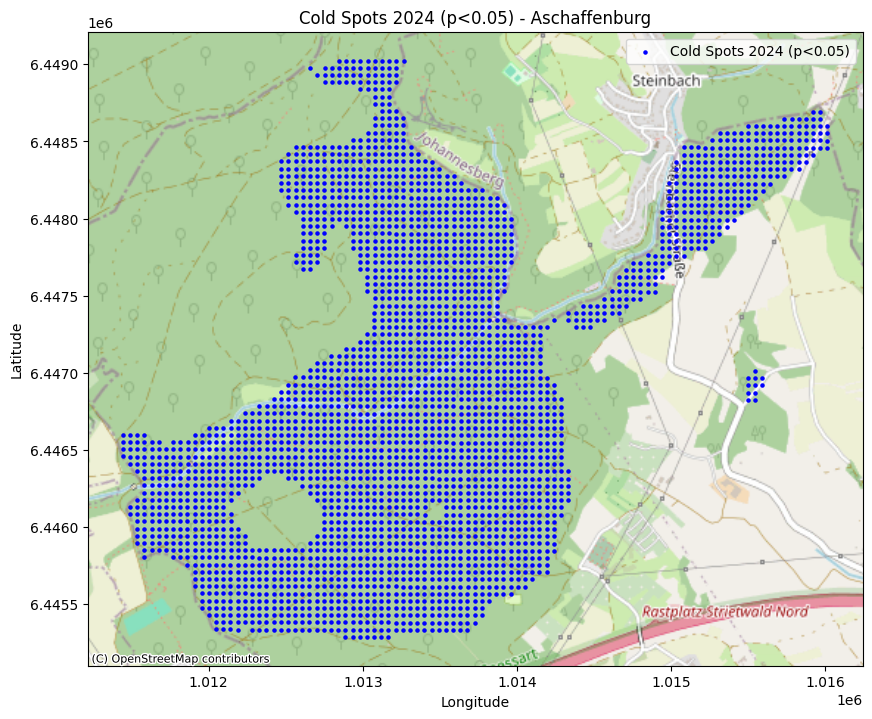

  Erstelle Karte für Cold Spots 2019-2024 (Aschaffenburg)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Aschaffenburg gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Augsburg (p005) ---
  Erstelle Karte für Cold Spots 2024 (Augsburg)...


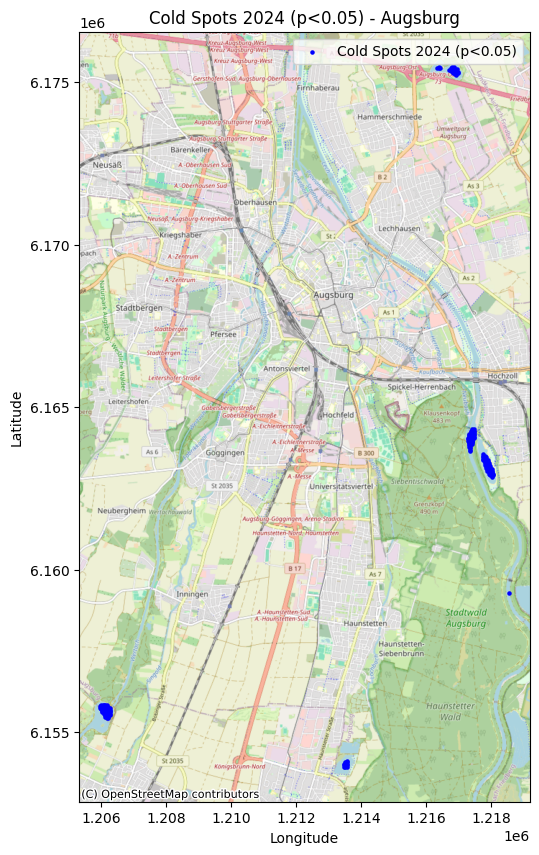

  Erstelle Karte für Cold Spots 2019-2024 (Augsburg)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Augsburg gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Bamberg (p005) ---
  Erstelle Karte für Cold Spots 2024 (Bamberg)...


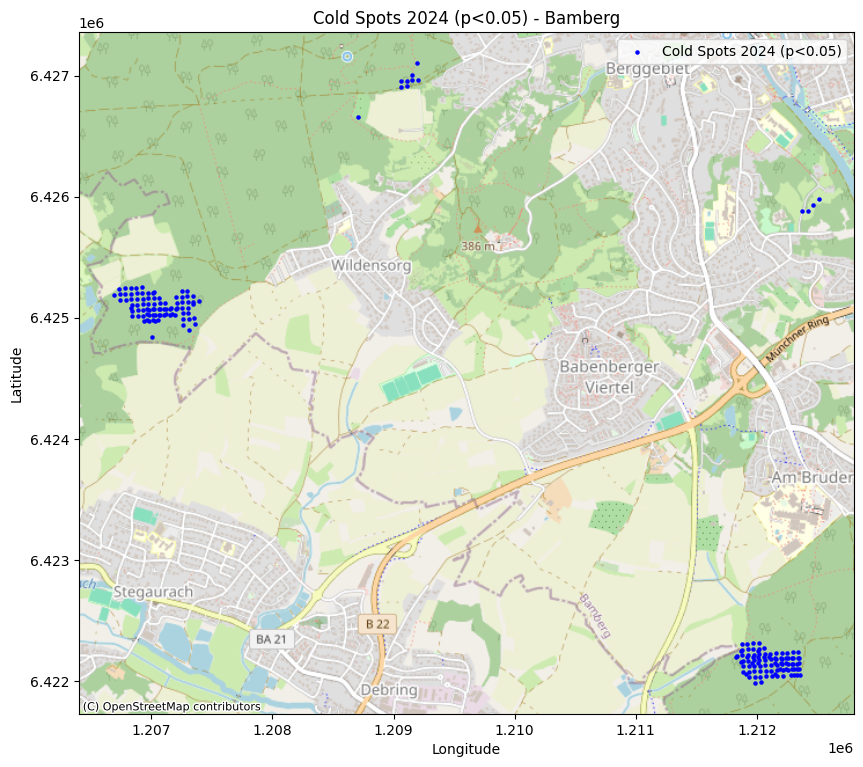

  Erstelle Karte für Cold Spots 2019-2024 (Bamberg)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Bamberg gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Bayreuth (p005) ---
  Erstelle Karte für Cold Spots 2024 (Bayreuth)...
  Keine Cold Spot Daten für 2024 (p<0.05) für Bayreuth gefunden. Karte wird nicht erstellt.
  Erstelle Karte für Cold Spots 2019-2024 (Bayreuth)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Bayreuth gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Erlangen (p005) ---
  Erstelle Karte für Cold Spots 2024 (Erlangen)...


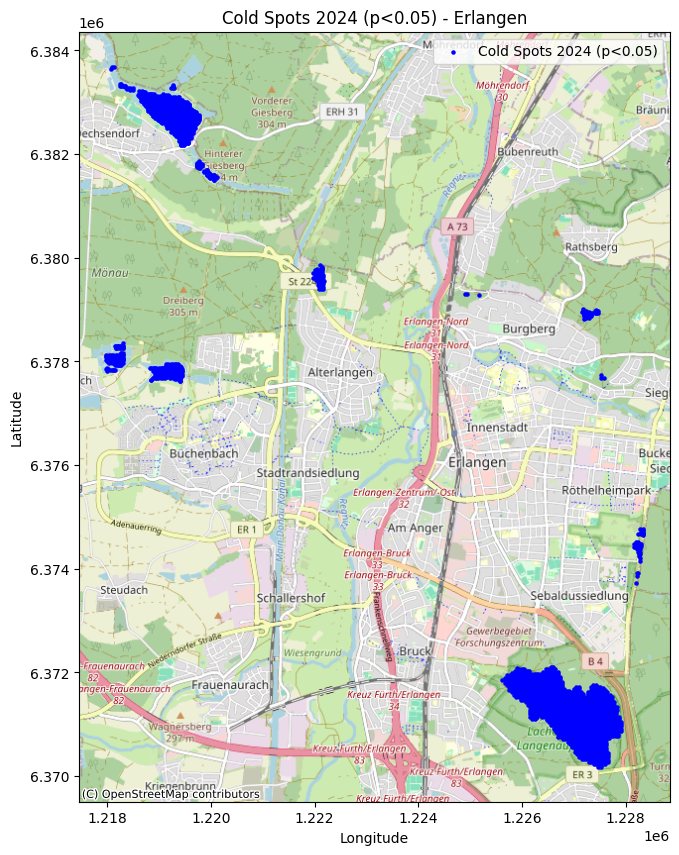

  Erstelle Karte für Cold Spots 2019-2024 (Erlangen)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Erlangen gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Fürth (p005) ---
  Erstelle Karte für Cold Spots 2024 (Fürth)...


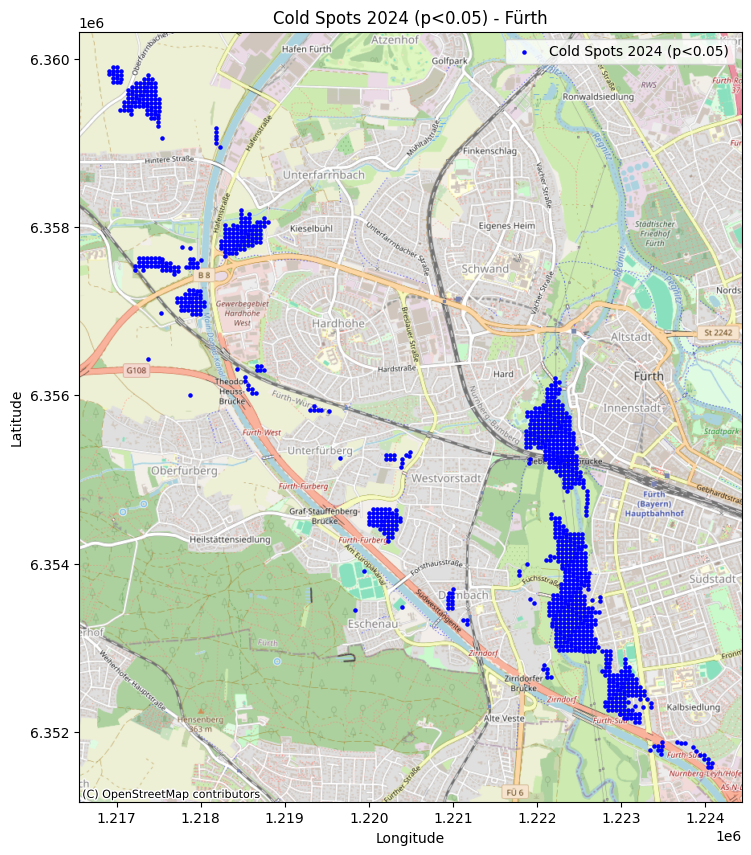

  Erstelle Karte für Cold Spots 2019-2024 (Fürth)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Fürth gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Ingolstadt (p005) ---
  Erstelle Karte für Cold Spots 2024 (Ingolstadt)...


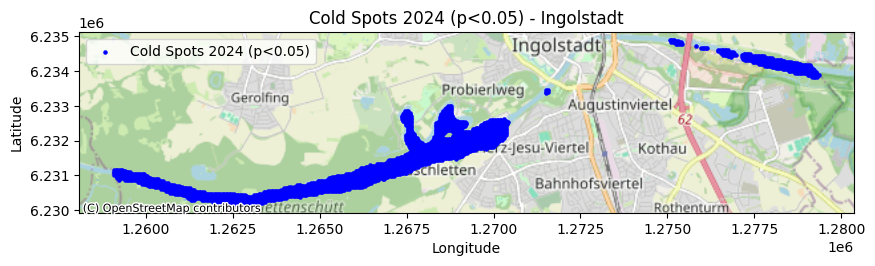

  Erstelle Karte für Cold Spots 2019-2024 (Ingolstadt)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Ingolstadt gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Kempten Allgäu (p005) ---
  Erstelle Karte für Cold Spots 2024 (Kempten Allgäu)...


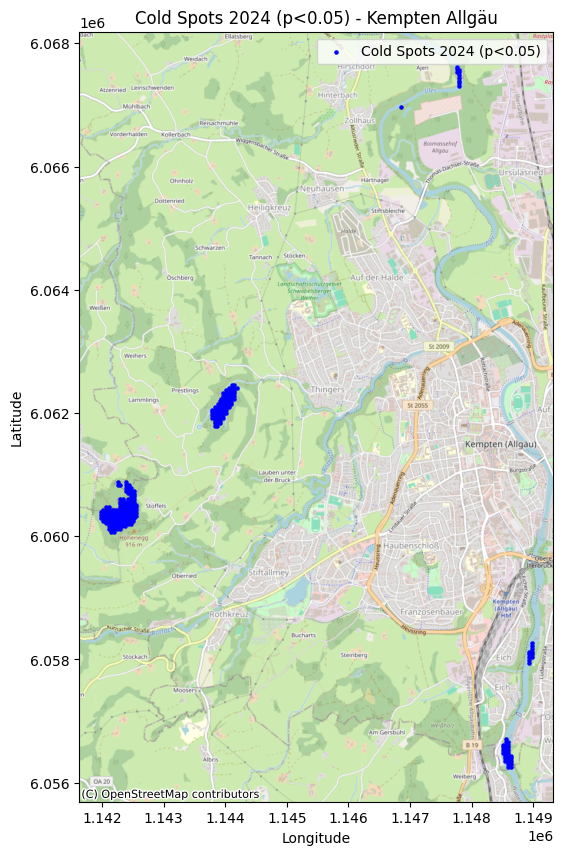

  Erstelle Karte für Cold Spots 2019-2024 (Kempten Allgäu)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Kempten Allgäu gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Landshut (p005) ---
  Erstelle Karte für Cold Spots 2024 (Landshut)...


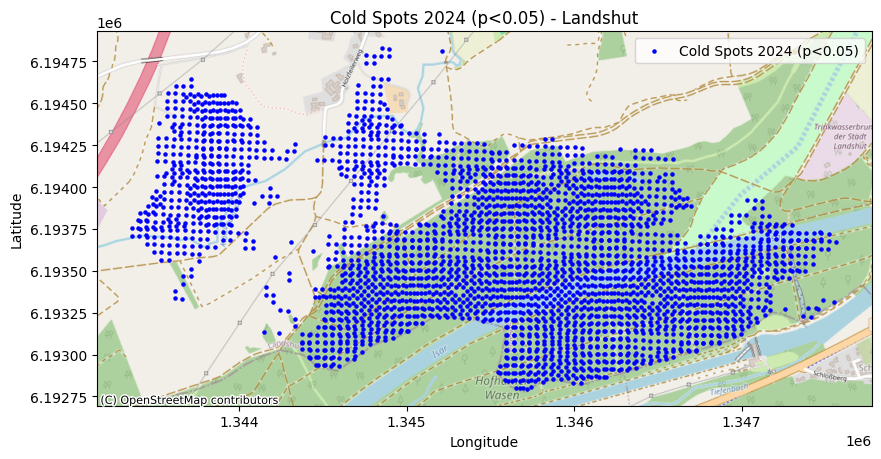

  Erstelle Karte für Cold Spots 2019-2024 (Landshut)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Landshut gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Nuremberg (p005) ---
  Erstelle Karte für Cold Spots 2024 (Nuremberg)...


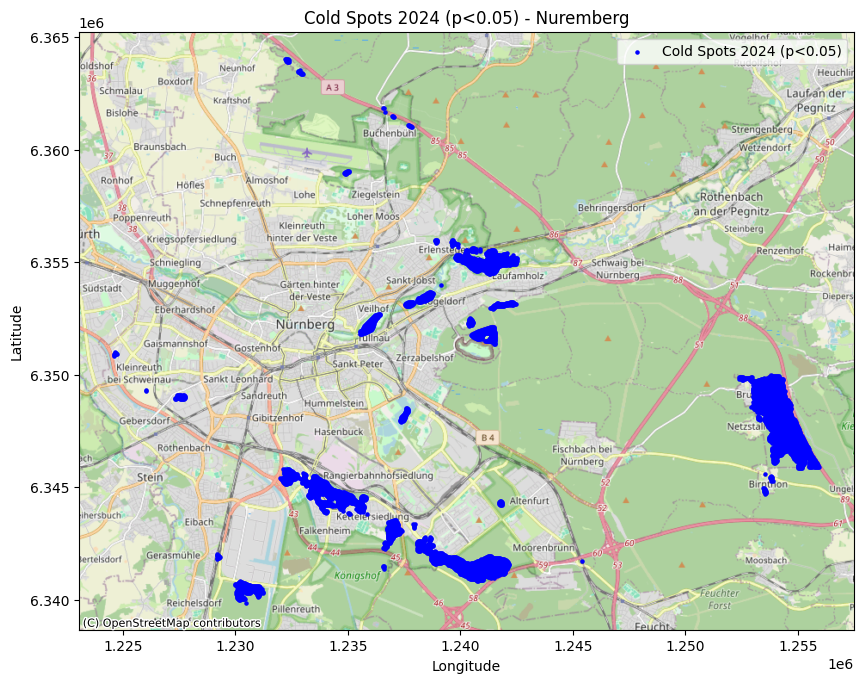

  Erstelle Karte für Cold Spots 2019-2024 (Nuremberg)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Nuremberg gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Passau (p005) ---
  Erstelle Karte für Cold Spots 2024 (Passau)...


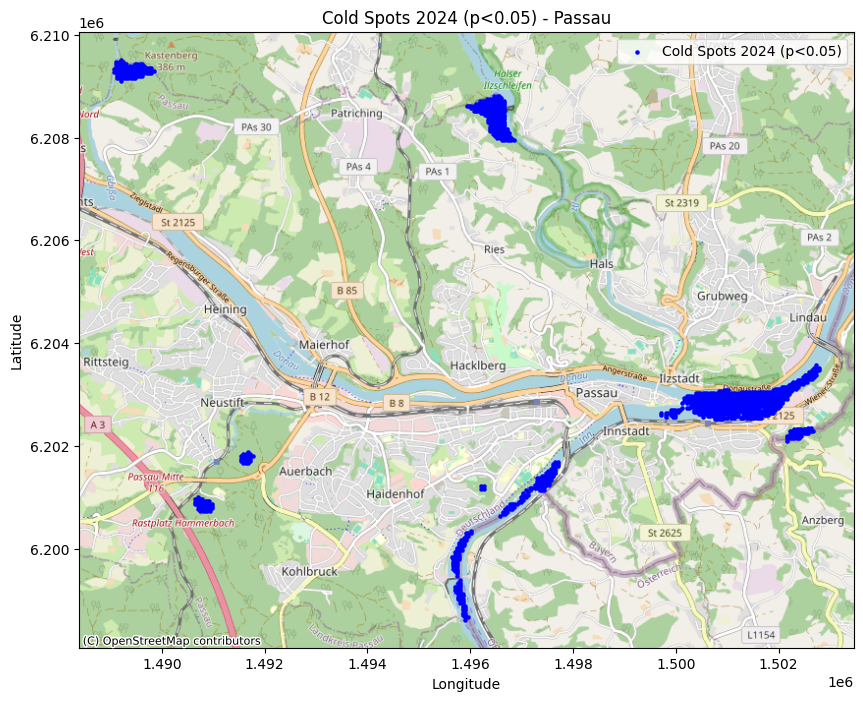

  Erstelle Karte für Cold Spots 2019-2024 (Passau)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Passau gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Regensburg (p005) ---
  Erstelle Karte für Cold Spots 2024 (Regensburg)...


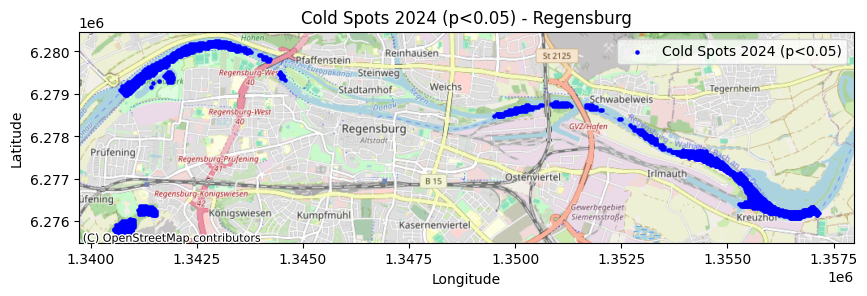

  Erstelle Karte für Cold Spots 2019-2024 (Regensburg)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Regensburg gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Rosenheim (p005) ---
  Erstelle Karte für Cold Spots 2024 (Rosenheim)...


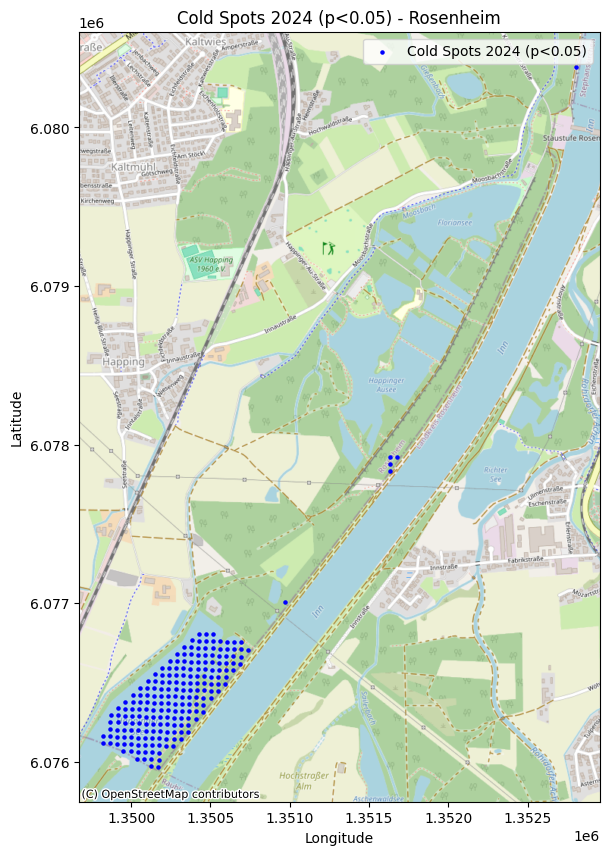

  Erstelle Karte für Cold Spots 2019-2024 (Rosenheim)...
  Keine Cold Spot Daten für 2019-2024 (p<0.05) für Rosenheim gefunden. Karte wird nicht erstellt.

--- Erstelle Karten für Schweinfurt (p005) ---
  Erstelle Karte für Cold Spots 2024 (Schweinfurt)...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backend_bases.py", line 2184, in print_figure
    result = print_method(
             ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
                                                                 ^^^^^
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backends/backend_agg.py", line 481, in print_png
    self._print_pil(filename_or_obj, "png", pil_kwargs, metadata)
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backends/backend_agg.py", line 429, in _print_pil
    FigureCanvasAgg.draw(self)
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/backends/backend_agg.py", line 382, in draw
    self.figure.draw(self.renderer)
  File "/usr/local/lib/python3.11/dist-packages/matplotlib/artist.py", line 94, in draw_wrapper
    result = d

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import os

# Define the output folder for the maps in Google Drive
output_maps_folder = "/content/drive/MyDrive/Cold Spots Bayern/cold_spot_maps/"
os.makedirs(output_maps_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Erstelle und speichere Karten der Cold Spots im Ordner: {output_maps_folder}")

# Get the list of cities from the loaded 2024 data (assuming it contains all cities)
cities = set(loaded_cold_spots_p005.keys()).union(set(loaded_cold_spots_p010.keys()))
cities = sorted(list(cities)) # Sort cities alphabetically for consistent output

# Define the coordinate reference system (CRS) for plotting
# It's recommended to use a projected CRS for accurate spatial operations and visualization
# A common choice for maps is Web Mercator (EPSG:3857)
output_crs = "EPSG:3857"

# Define which significance level to plot (p005 or p010)
significance_level_to_plot = 'p005' # Change to 'p010' to plot p<0.10 data

print(f"\nErstelle Karten für Cold Spots mit Signifikanzlevel: p<{significance_level_to_plot.replace('p0', '0.')}...")

# Iterate through each city and create maps for both time periods
for city in cities:
    print(f"\n--- Erstelle Karten für {city} ({significance_level_to_plot}) ---")

    # --- Map for Cold Spots 2024 ---
    print(f"  Erstelle Karte für Cold Spots 2024 ({city})...")
    # Select the correct loaded data based on significance level
    if significance_level_to_plot == 'p005':
        loaded_data_2024 = loaded_cold_spots_p005
        sig_label = 'p<0.05'
    elif significance_level_to_plot == 'p010':
        loaded_data_2024 = loaded_cold_spots_p010
        sig_label = 'p<0.10'
    else:
        print(f"  Ungültiges Signifikanzniveau '{significance_level_to_plot}'. Überspringe 2024 Karte für {city}.")
        loaded_data_2024 = None # Skip plotting if significance level is invalid


    if loaded_data_2024 is not None and city in loaded_data_2024 and not loaded_data_2024[city].empty:
        gdf_2024 = loaded_data_2024[city].to_crs(output_crs) # Reproject to output_crs

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        gdf_2024.plot(ax=ax, marker='o', color='blue', markersize=5, label=f'Cold Spots 2024 ({sig_label})')

        # Add basemap
        try:
            ctx.add_basemap(ax, crs=output_crs, source=ctx.providers.OpenStreetMap.Mapnik)
        except Exception as e:
            print(f"    Fehler beim Hinzufügen der Basemap für 2024 Karte von {city}: {e}")
            # Fallback to plotting without basemap if it fails
            pass


        ax.set_title(f'Cold Spots 2024 ({sig_label}) - {city}')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend()
        plt.show() # Display the plot

        # Save the map (optional, uncomment if needed)
        # file_name_2024 = f"{city.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2024_{significance_level_to_plot}_map.png"
        # file_path_2024 = os.path.join(output_maps_folder, file_name_2024)
        # try:
        #     plt.savefig(file_path_2024, dpi=300)
        #     print(f"    Karte für 2024 gespeichert: {file_path_2024}")
        # except Exception as e:
        #     print(f"    Fehler beim Speichern der Karte für 2024 von {city}: {e}")

        plt.close(fig) # Close the plot to free memory
        del gdf_2024 # Free up memory

    else:
        print(f"  Keine Cold Spot Daten für 2024 ({sig_label}) für {city} gefunden. Karte wird nicht erstellt.")


    # --- Map for Cold Spots 2019-2024 ---
    print(f"  Erstelle Karte für Cold Spots 2019-2024 ({city})...")
    # Select the correct loaded data based on significance level
    if significance_level_to_plot == 'p005':
        loaded_data_2019_2024 = loaded_cold_spots_p005_2019_2024
        sig_label = 'p<0.05'
        file_suffix = '_p005.geojson'
    elif significance_level_to_plot == 'p010':
        loaded_data_2019_2024 = loaded_cold_spots_p010_2019_2024
        sig_label = 'p<0.10'
        file_suffix = '_p010.geojson'
    else:
         print(f"  Ungültiges Signifikanzniveau '{significance_level_to_plot}'. Überspringe 2019-2024 Karte für {city}.")
         loaded_data_2019_2024 = None # Skip plotting if significance level is invalid
         file_suffix = None


    if loaded_data_2019_2024 is not None and file_suffix is not None:
        # Construct the key for the 2019-2024 dictionaries based on the city name and filename format
        # Use the city name as loaded, replace spaces with underscores, and add the suffix
        city_key_2019_2024 = f"{city.replace(' ', '_')}_cold_spots{file_suffix}"

        # Handle specific city names with umlauts or special characters that might have different key formats during loading
        # We'll check for the exact keys that were loaded into the dictionaries
        actual_key_2019_2024 = None
        for key in loaded_data_2019_2024.keys():
            # Create a simplified version of the key for comparison (lowercase, no spaces, no special chars)
            simplified_key = key.lower().replace(" ", "").replace("_", "").replace("-", "").replace("(", "").replace(")", "").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss").replace("geojson", "")
            simplified_city = city.lower().replace(" ", "").replace("_", "").replace("-", "").replace("(", "").replace(")", "").replace("ä", "ae").replace("ö", "oe").replace("ü", "ue").replace("ß", "ss")

            if simplified_city in simplified_key:
                 # Further check if the significance level suffix matches
                 if (significance_level_to_plot == 'p005' and '_p005.geojson' in key) or \
                    (significance_level_to_plot == 'p010' and '_p010.geojson' in key):
                     actual_key_2019_2024 = key
                     break # Found the matching key


        if actual_key_2019_2024 is not None and not loaded_data_2019_2024[actual_key_2019_2024].empty:
            gdf_2019_2024 = loaded_data_2019_2024[actual_key_2019_2024].to_crs(output_crs) # Reproject
        else:
             gdf_2019_2024 = None # No data found


        if gdf_2019_2024 is not None:
            fig, ax = plt.subplots(1, 1, figsize=(10, 10))
            gdf_2019_2024.plot(ax=ax, marker='o', color='red', markersize=5, label=f'Cold Spots 2019-2024 ({sig_label})')

            # Add basemap
            try:
                ctx.add_basemap(ax, crs=output_crs, source=ctx.providers.OpenStreetMap.Mapnik)
            except Exception as e:
                print(f"    Fehler beim Hinzufügen der Basemap für 2019-2024 Karte von {city}: {e}")
                # Fallback to plotting without basemap if it fails
                pass


            ax.set_title(f'Cold Spots 2019-2024 ({sig_label}) - {city}')
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            ax.legend()
            plt.show() # Display the plot

            # Save the map (optional, uncomment if needed)
            # file_name_2019_2024 = f"{city.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2019_2024_{significance_level_to_plot}_map.png"
            # file_path_2019_2024 = os.path.join(output_maps_folder, file_name_2019_2024)
            # try:
            #     plt.savefig(file_path_2019_2024, dpi=300)
            #     print(f"    Karte für 2019-2024 gespeichert: {file_path_2019_2024}")
            # except Exception as e:
            #     print(f"    Fehler beim Speichern der Karte für 2019-2024 von {city}: {e}")


            plt.close(fig) # Close the plot to free memory
            del gdf_2019_2024 # Free up memory

        else:
            print(f"  Keine Cold Spot Daten für 2019-2024 ({sig_label}) für {city} gefunden. Karte wird nicht erstellt.")

    else:
         print(f"  Überspringe 2019-2024 Karte für {city} aufgrund ungültigen Signifikanzlevels oder fehlendem Dateisuffix.")


print("\nKartenerstellung abgeschlossen.")

für Gesamtzwitraum werden Daten nicht richtig geladen womöglich weil Benennung anders,...